# ❄️ Snowfall Derivatives Pricing — New York City ❄️

In this project we will price weather derivatives call options for snowfall in NYC. We will do this first using a statistical model built from historical data. We will also use this data to model the trend of snowfall over time. We will then consider a relatively simple physical model where snowfall is based on tempurature and percipitation. Then we combine these two models into a hybrid model. Last we will take a look at how changing the initial strike affects the payoffs for each model.



## Setup and Configuration

In [2]:
# Import libraries to use and set seed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os
import time

sns.set(style="whitegrid")
np.random.seed(99)



In [3]:
# Setup parameters
strike = 27.5 #inches of snow
pay_per_in = 1000 # $ amount per inch of snow above strike
rate = 0.03 #rate of $ value change
n_simulations = 100000
season_months = [12, 1, 2] #Winter months



In [4]:
# NOAA Configuration to get snow data
TOKEN = "UTmhxJklLqIcNdMRyNdYlVDIgWJMWAlz"
STATION_ID = "GHCND:USW00094728" #Location: New York City (Central Park station)
BASE_URL = "https://www.ncdc.noaa.gov/cdo-web/api/v2/data"
HEADERS = {"token": TOKEN}

## Data collection

### Get data

In [5]:
def fetch_snowfall_data(start_year=1950, end_year=2024):
    all_data = []

    for year in range(start_year, end_year + 1):
        print(f"Fetching {year}...")

        params = {
            "datasetid": "GHCND",
            "stationid": STATION_ID,
            "datatypeid": "SNOW",
            "startdate": f"{year}-01-01",
            "enddate": f"{year}-12-31",
            "limit": 1000,
            "offset": 1
        }

        while True:
            response = requests.get(BASE_URL, headers=HEADERS, params=params)

            if response.status_code != 200:
                print("Error:", response.text)
                break

            data = response.json().get("results", [])
            if not data:
                break

            all_data.extend(data)

            params["offset"] += params["limit"]
            time.sleep(0.2)

    return all_data

### Process data

In [6]:
def process_data(raw_data):
    df = pd.DataFrame(raw_data)
    df = df[["date", "value"]].copy()
    df.rename(columns={"value": "snowfall_raw"}, inplace=True)

    # NOAA: tenths of mm → inches
    df["snowfall"] = df["snowfall_raw"] / 25.4

    df["date"] = pd.to_datetime(df["date"])
    return df[["date", "snowfall"]]


def get_or_load_data(filepath="snowfall_nyc.csv"):
    if os.path.exists(filepath):
        print("Loading cached data...")
        return pd.read_csv(filepath, parse_dates=["date"])

    print("Fetching from NOAA...")
    raw = fetch_snowfall_data()
    df = process_data(raw)
    df.to_csv(filepath, index=False)
    print("Saved to CSV")
    return df


df = get_or_load_data()
df.head()

Loading cached data...


,date,snowfall
0,1950-01-01,0.0
1,1950-01-02,0.0
2,1950-01-03,0.0
3,1950-01-04,0.0
4,1950-01-05,0.0


In [7]:
def process_data(raw_data):
    df = pd.DataFrame(raw_data)
    df = df[["date", "value"]].copy()
    df.rename(columns={"value": "snowfall_raw"}, inplace=True)

    # NOAA: tenths of mm → inches
    df["snowfall"] = df["snowfall_raw"] / 25.4

    df["date"] = pd.to_datetime(df["date"])
    return df[["date", "snowfall"]]


def get_or_load_data(filepath="snowfall_nyc.csv", force_refresh=False):
    if os.path.exists(filepath) and not force_refresh:
        print("Loading cached data...")
        return pd.read_csv(filepath, parse_dates=["date"])

    print("Fetching from NOAA...")
    raw = fetch_snowfall_data()
    df = process_data(raw)
    df.to_csv(filepath, index=False)
    return df


df = get_or_load_data(force_refresh=True)
df.head()

Fetching from NOAA...
Fetching 1950...
Fetching 1951...
Fetching 1952...
Error: <!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">
<html><head>
<title>503 Service Unavailable</title>
</head><body>
<h1>Service Unavailable</h1>
<p>The server is temporarily unable to service your
request due to maintenance downtime or capacity
problems. Please try again later.</p>
<p>Additionally, a 503 Service Unavailable
error was encountered while trying to use an ErrorDocument to handle the request.</p>
</body></html>

Fetching 1953...
Fetching 1954...
Fetching 1955...
Fetching 1956...
Fetching 1957...
Fetching 1958...
Fetching 1959...
Fetching 1960...
Fetching 1961...
Fetching 1962...
Fetching 1963...
Fetching 1964...
Fetching 1965...
Fetching 1966...
Fetching 1967...
Fetching 1968...
Fetching 1969...
Fetching 1970...
Fetching 1971...
Fetching 1972...
Fetching 1973...
Fetching 1974...
Fetching 1975...
Fetching 1976...
Fetching 1977...
Fetching 1978...
Fetching 1979...
Fetching 1980...
Fetching 1981..

,date,snowfall
0,1950-01-01,0.0
1,1950-01-02,0.0
2,1950-01-03,0.0
3,1950-01-04,0.0
4,1950-01-05,0.0


In [8]:
print(df["snowfall"].describe())
print(df["snowfall"].max())
print(df["snowfall"].head(10))

count    27028.000000
mean         0.070128
std          0.632834
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         27.283465
Name: snowfall, dtype: float64
27.283464566929137
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
7    0.0
8    0.0
9    0.0
Name: snowfall, dtype: float64


Data Analysis

In [9]:
df.describe()

,date,snowfall
count,27028,27028.000000
mean,1987-04-24 20:17:05.070297472,0.070128
min,1950-01-01 00:00:00,0.000000
25%,1968-07-02 18:00:00,0.000000
50%,1987-01-01 12:00:00,0.000000
75%,2006-07-02 06:00:00,0.000000
max,2024-12-31 00:00:00,27.283465
std,NaN,0.632834


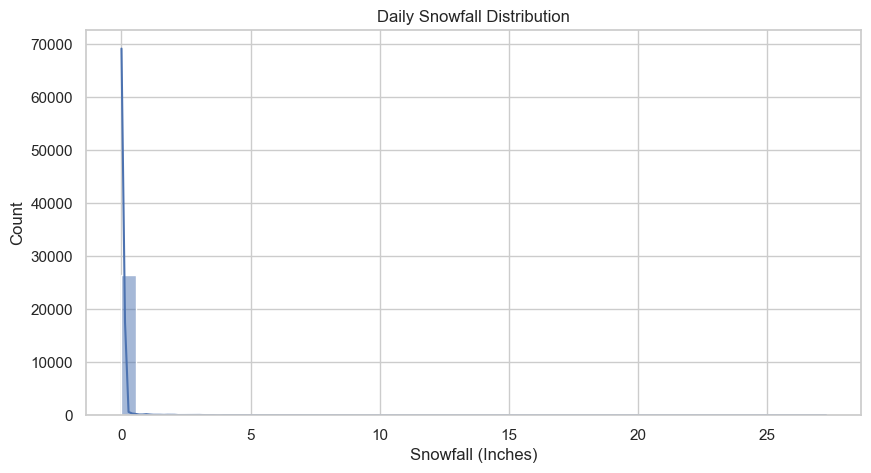

In [10]:
# --- Plot Distribution of Daily Snowfall ---
plt.figure(figsize=(10,5))
sns.histplot(df["snowfall"], bins=50, kde=True)
plt.title("Daily Snowfall Distribution")
plt.xlabel("Snowfall (Inches)")
plt.show()

Most days, it does not snow, as we expect.

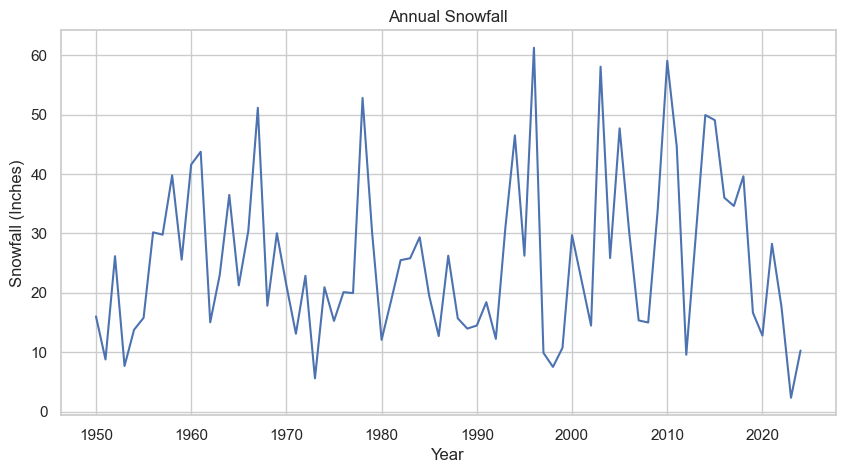

In [11]:
# --- Plot Annual Snowfall ---
df["year"] = df["date"].dt.year
annual = df.groupby("year")["snowfall"].sum()

annual.plot(figsize=(10,5), title="Annual Snowfall")
plt.ylabel("Snowfall (Inches)")
plt.xlabel("Year")
plt.show()

# Seasonal Aggregation

Right now we have the amount of snowfall per year, but we are interested in the winter months specifically. We also need to account for the fact that the december month in the season occurs during the previous calendar year.

In [12]:
def seasonal_snowfall(df):
    '''
    Calculate the total snowfall in inches per year
    '''
    df = df.copy()
    df["month"] = df["date"].dt.month
    df["year"] = df["date"].dt.year

    df = df[df["month"].isin(season_months)]

    # December belongs to next winter
    df.loc[df["month"] == 12, "year"] += 1

    seasonal = df.groupby("year")["snowfall"].sum()
    return seasonal


seasonal = seasonal_snowfall(df)
seasonal.head()

year
1950     8.897638
1951     6.614173
1952    12.401575
1953    12.047244
1954    13.228346
Name: snowfall, dtype: float64

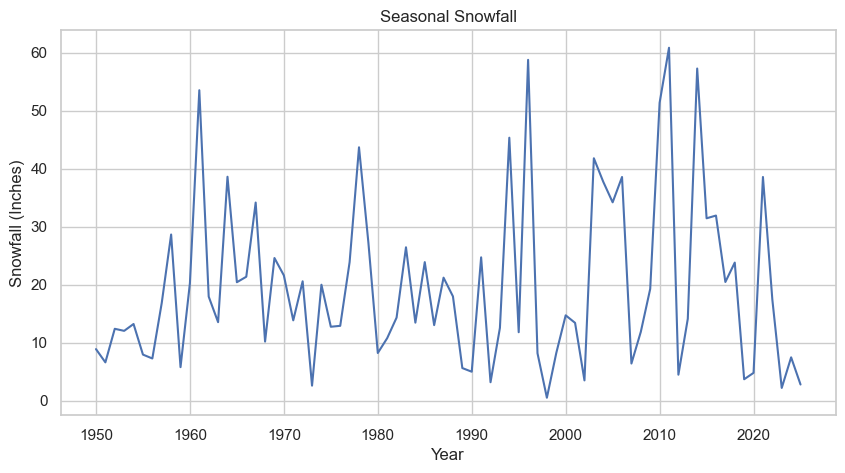

In [57]:
# --- Plot Seasonal Snowfall ---
seasonal.plot(figsize=(10,5), title="Seasonal Snowfall")
plt.ylabel("Snowfall (Inches)")
plt.xlabel("Year")
plt.savefig("Seasonal_Snowfall.png", format='png', dpi=300, bbox_inches='tight') 
plt.show()

# Climate trend

To model how the annual snowfall changes over time, we take a simple linear model for the trend.
$$ S_t=S_0+b*t$$

In [14]:
years = seasonal.index.values
snowfall = seasonal.values

slope, intercept = np.polyfit(years, snowfall, 1)
print("Trend slope:", slope)
print("Trend intercept:", intercept)

Trend slope: 0.07128002540352406
Trend intercept: -121.91304137222261


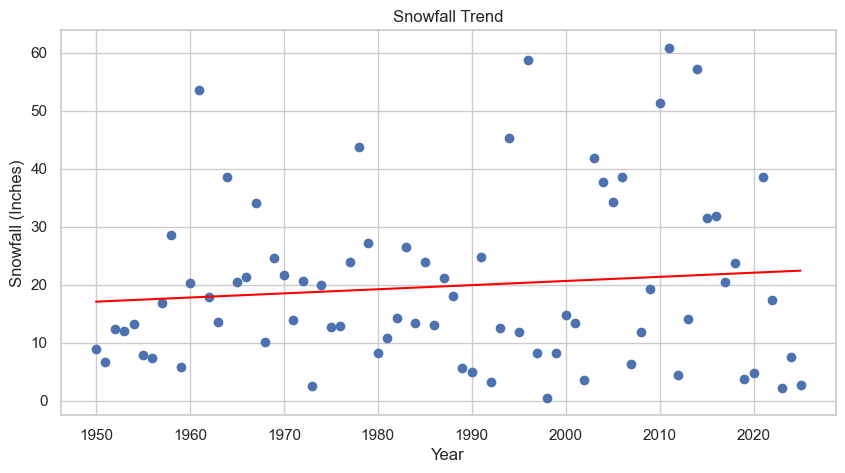

In [58]:
# --- Plot Snowfall Trend---
trend = slope * years + intercept

plt.figure(figsize=(10,5))
plt.scatter(years, snowfall)
plt.plot(years, trend, color="red")
plt.xlabel("Year")
plt.ylabel("Snowfall (Inches)")
plt.title("Snowfall Trend")
plt.savefig("Snowfall_Trend.png",format='png', dpi=300, bbox_inches='tight') 
plt.show()

# Statistical model

### Simulation

In [16]:
#Statistical
sim_statistical = np.random.choice(snowfall, size=n_simulations, replace=True)

#Trend-adjusted
future_year = years.max() + 1
trend_adjustment = slope * (future_year - years.max())

sim_trend = np.random.choice(snowfall, size=n_simulations, replace=True) + trend_adjustment

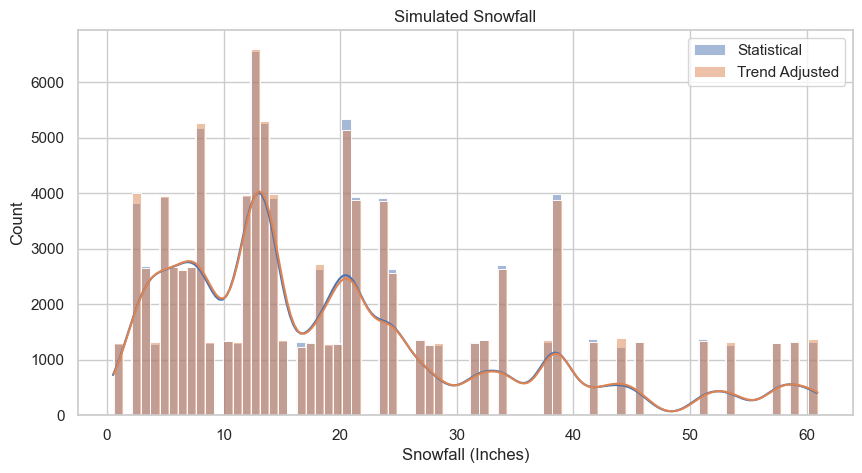

In [17]:
# --- Plot Simulated Snowfall ---
plt.figure(figsize=(10,5))
sns.histplot(sim_statistical, label="Statistical", kde=True)
sns.histplot(sim_trend, label="Trend Adjusted", kde=True, alpha = 0.5)
plt.legend()
plt.xlabel("Snowfall (Inches)")
plt.title("Simulated Snowfall")
plt.show()

##  Physical Snowfall Model

In addition to statistical models, we build a simple physically motivated snowfall model based on temperature and precipitation dynamics.

### Model Choices

1. **Temperature (T)**
   - Daily temperature sampled from a normal distribution:  
     $$T \sim N(\mu_{temp}, \sigma_{temp})$$  
   - Mean $\mu_{temp}$ chosen to reflect NYC winter (Dec–Feb).  
   - Standard deviation $\sigma_{temp}$ captures daily variability.

2. **Precipitation Occurrence**
   - Not all days have precipitation.  
   - Modeled as a Bernoulli trial:  
     $$P_{precip} \sim Bernoulli(p_{precip})$$  
   - Typical probability $p_{precip} \equiv 0.3$ (30% of winter days).

3. **Precipitation Amount (R)**
   - When there is percipitation, amount drawn from an exponential distribution:  
     $$R \sim Exponential(\lambda)$$  
   - Reflects skewed distribution of light vs heavy precipitation events.

4. **Probability of Snow (p_snow)**
   - Logistic function of temperature:  
     $$p_{snow} = \frac{1}{  (1 + \exp(\alpha*(T-T_0)))}$$  
   - Colder temperatures increase probability of snow.


In [18]:
def simulate_physical_snowfall(n_days, mean_temp=1.5, temp_std=5, precip_prob=0.3, precip_scale=3):
    """
    Simulate daily snowfall (inches) for n_days using physical model.
    
    Parameters:
    - n_days: int, number of days in the season
    - mean_temp: float, average daily temperature (°C)
    - temp_std: float, standard deviation of daily temperature
    - precip_prob: float, probability of precipitation each day
    - precip_scale: float, scale parameter for exponential precipitation (mm)
    
    Returns:
    - np.array of daily snowfall in inches
    """
    snowfall = []

    for _ in range(n_days):
        # Temperature (°C)
        temp = np.random.normal(loc=mean_temp, scale=temp_std)

        # Precipitation occurrence
        if np.random.rand() < precip_prob:
            precip = np.random.exponential(scale=precip_scale)
            # Probability of snow (logistic)
            p_snow = 1 / (1 + np.exp(0.8 * (temp - 1)))

            if np.random.rand() < p_snow:
                snow_ratio = np.clip(10 - 0.5 * temp, 5, 15)
                snow = precip * snow_ratio / 25.4  # convert mm → inches
            else:
                snow = 0
        else:
            snow = 0

        snowfall.append(snow)

    return np.array(snowfall)

In [19]:
def simulate_season_physical(n_simulations, n_days=90,
                             mean_temp=1.5, temp_std=5, precip_prob=0.3, precip_scale=3):
    """
    Simulate total seasonal snowfall over multiple seasons.

    Parameters:
    - n_simulations: number of seasons to simulate
    - n_days: number of days per season
    - mean_temp: average daily temperature (°C)
    - temp_std: standard deviation of daily temperature (°C)
    - precip_prob: probability of precipitation on a given day
    - precip_scale: scale parameter for exponential precipitation (mm)

    Returns:
    - numpy array of total seasonal snowfall (inches) for each simulation
    """
    seasonal_totals = []

    for _ in range(n_simulations):
        daily_snow = simulate_physical_snowfall(n_days, mean_temp, temp_std, precip_prob, precip_scale)
        seasonal_totals.append(np.sum(daily_snow))

    return np.array(seasonal_totals)

In [20]:
sim_physical = simulate_season_physical(n_simulations)

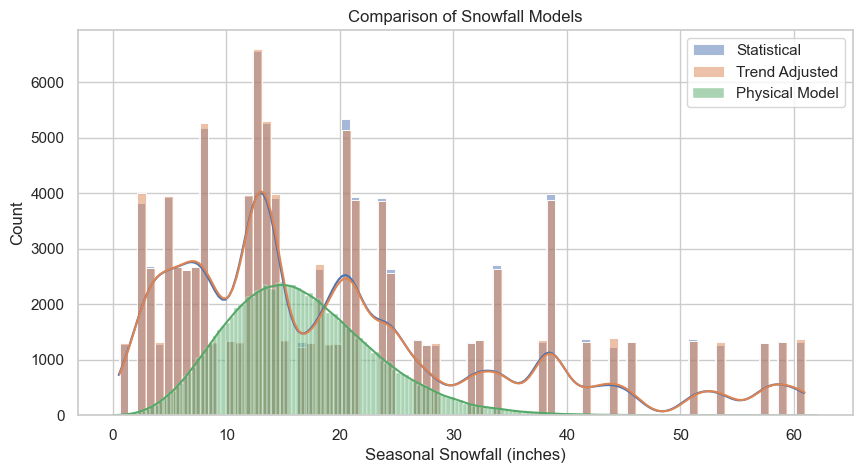

In [59]:
# --- Plot Simulated Snowfall ---
plt.figure(figsize=(10,5))

sns.histplot(sim_statistical, label="Statistical", kde=True)
sns.histplot(sim_trend, label="Trend Adjusted", kde=True)
sns.histplot(sim_physical, label="Physical Model", kde=True)

plt.legend()
plt.title("Comparison of Snowfall Models")
plt.xlabel("Seasonal Snowfall (inches)")
plt.savefig("Comparison_Snowfall_No_Hybrid.png", format='png', dpi=300, bbox_inches='tight') 
plt.show()

# Derivative Pricing for Statistical and Physical Models

In [22]:
# --- Derivative Pricing Function ---
def price_derivative(simulated, strike, pay_per_in, rate, t=1, risk_loading=0.1):
    """
    Prices a snowfall call option using Monte Carlo simulation with
    continuous discounting and risk loading.

    Parameters:
    - simulated: array of simulated seasonal snowfall (inches)
    - strike: strike level (inches)
    - pay_per_in: payout per inch above strike ($/inch)
    - rate: annual risk-free discount rate 
    - t: time to maturity in years (t=1 for a seasonal contract)
    - risk_loading: additional premium to account for unhedgeable risk
      

    Returns:
    - price: discounted and risk-adjusted expected payoff
    - payoffs: array of simulated payoffs before discounting
    """
    payoffs = np.maximum(0, simulated - strike) * pay_per_in
    
    expected_payoff = np.mean(payoffs)
    
    # Add risk premium
    loaded_payoff = expected_payoff * (1 + risk_loading)
    
    # Discount to present value
    price = loaded_payoff * np.exp(-rate * t)
    
    return price, payoffs

In [23]:
# --- Pricing: Statistical and Trend Models ---

price_stat, payoffs_stat = price_derivative(sim_statistical, strike, pay_per_in, rate)
price_trend, payoffs_trend = price_derivative(sim_trend, strike, pay_per_in, rate)

print("=== Statistical vs Trend Pricing ===")
print(f"Price (Statistical): {price_stat:.2f}")
print(f"Price (Trend): {price_trend:.2f}")

=== Statistical vs Trend Pricing ===
Price (Statistical): 3660.98
Price (Trend): 3697.62


In [24]:
# --- Pricing: Physical Model ---

price_phys, payoffs_phys = price_derivative(sim_physical, strike, pay_per_in, rate)

print("=== Physical Model Pricing ===")
print(f"Price (Physical): {price_phys:.2f}")

=== Physical Model Pricing ===
Price (Physical): 232.84


## Results

In [25]:
# --- Summary Statistics for All Models ---
summary = pd.DataFrame({
    "Model": ["Statistical", "Trend", "Physical"],
    "Expected Payoff ($)": [
        np.mean(payoffs_stat),
        np.mean(payoffs_trend),
        np.mean(payoffs_phys)
    ],
    "Std Dev of Payoff ($)": [
        np.std(payoffs_stat),
        np.std(payoffs_trend),
        np.std(payoffs_phys)
    ],
    "Payout Probability": [
        np.mean(payoffs_stat > 0),
        np.mean(payoffs_trend > 0),
        np.mean(payoffs_phys > 0)
    ]
})

summary.set_index("Model", inplace=True)
summary = summary.round(2)

print("=== Payout Summary ===")
display(summary)

=== Payout Summary ===


,Expected Payoff ($),Std Dev of Payoff ($),Payout Probability
Model,,,
Statistical,3429.53,7901.38,0.23
Trend,3463.85,7963.89,0.22
Physical,218.11,1214.93,0.06


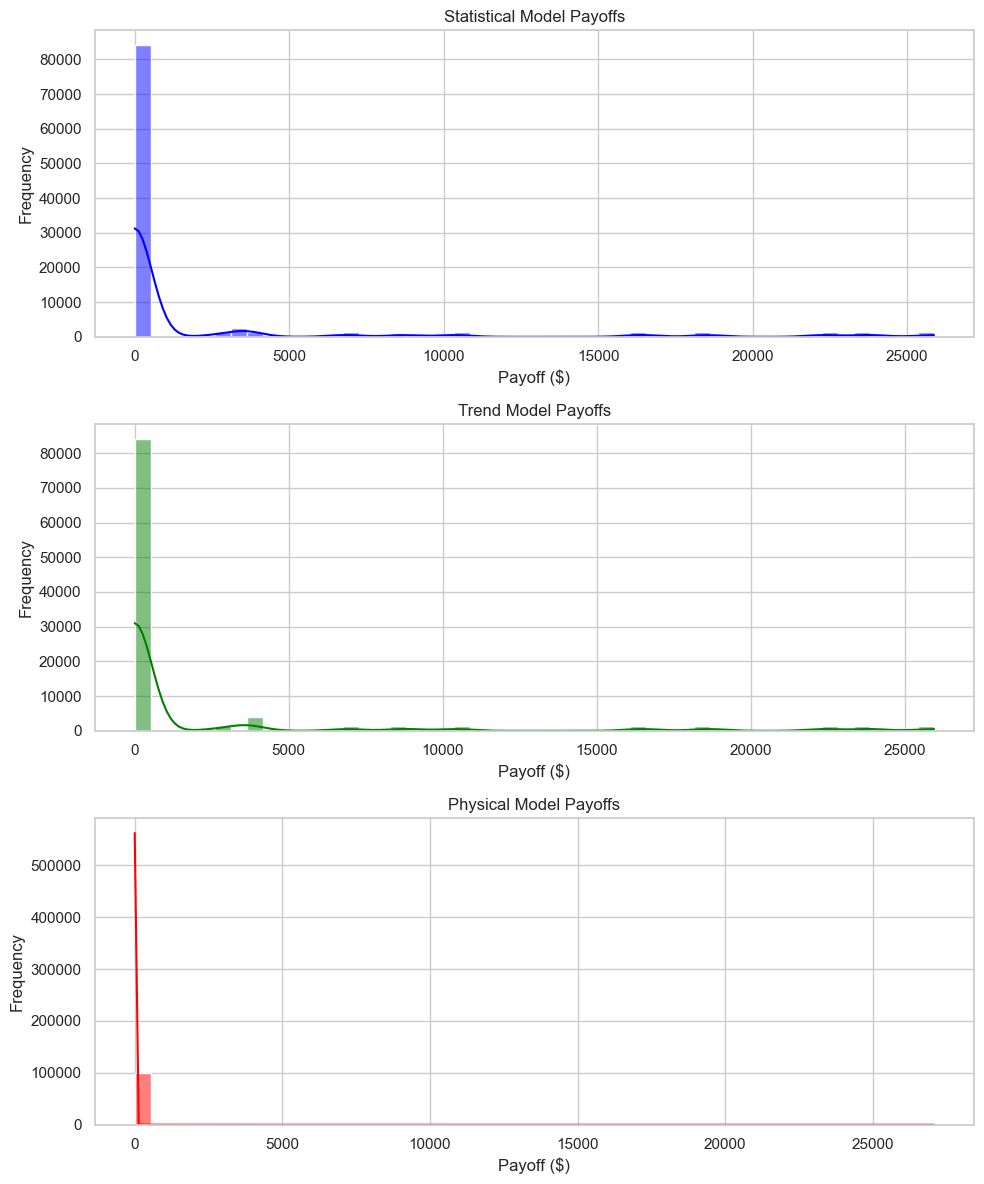

In [64]:
# --- Histogram of Payoffs---

plt.figure(figsize=(10, 12))

# Statistical
plt.subplot(3, 1, 1)
sns.histplot(payoffs_stat, bins=50, kde=True, color='blue')
plt.title("Statistical Model Payoffs")
plt.xlabel("Payoff ($)")
plt.ylabel("Frequency")

# Trend
plt.subplot(3, 1, 2)
sns.histplot(payoffs_trend, bins=50, kde=True, color='green')
plt.title("Trend Model Payoffs")
plt.xlabel("Payoff ($)")
plt.ylabel("Frequency")

# Physical
plt.subplot(3, 1, 3)
sns.histplot(payoffs_phys, bins=50, kde=True, color='red')
plt.title("Physical Model Payoffs")
plt.xlabel("Payoff ($)")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("Model_Payoff_Comparison_No_Hybrid.png", format='png', dpi=300, bbox_inches='tight')

plt.show()

We see a large tail at 0 corresponding to all the scenarios where the snowfall is less than the strike.

In [65]:
# --- Save each model histogram as separate PNG ---

# Statistical Model
plt.figure(figsize=(8, 5))
sns.histplot(payoffs_stat, bins=50, kde=True, color='blue')
plt.title("Statistical Model Payoffs")
plt.xlabel("Payoff ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("Payoffs_Statistical.png", dpi=300)
plt.close()

# Trend Model
plt.figure(figsize=(8, 5))
sns.histplot(payoffs_trend, bins=50, kde=True, color='green')
plt.title("Trend Model Payoffs")
plt.xlabel("Payoff ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("Payoffs_Trend.png", dpi=300)
plt.close()

# Physical Model
plt.figure(figsize=(8, 5))
sns.histplot(payoffs_phys, bins=50, kde=True, color='red')
plt.title("Physical Model Payoffs")
plt.xlabel("Payoff ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("Payoffs_Physical.png", dpi=300)
plt.close()

# Hybrid physical and statistical model

The hybrid model starts with the physical simulation of daily snowfall and then adds a climate-driven trend adjustment to capture long-term changes.

### Model Components

- **Physical Component**  
Seasonal snowfall is first generated using the physical model:
$$
S_\text{season}^\text{physical} = \sum_{i=1}^{90} S_{\text{day},i}
$$

- **Trend Adjustment**  
A linear trend is added to reflect climate effects:
$$
\text{Trend Adjustment} = b \cdot t
$$

- **Hybrid Model**  
The final hybrid snowfall is:
$$
S_\text{season}^\text{hybrid} = S_\text{season}^\text{physical} + b \cdot t
$$



In [27]:
def compute_residuals(seasonal_data, n_sim=1000):
    #Simulate physical model many times
    sim_phys = simulate_season_physical(n_sim)

    #Align sizes
    hist = np.random.choice(seasonal_data, size=n_sim, replace=True)

    residuals = hist - sim_phys
    return residuals

In [28]:
def simulate_hybrid(seasonal_data, n_simulations):
    #Physical component
    sim_phys = simulate_season_physical(n_simulations)

    #Residual component (data-driven noise)
    residuals = compute_residuals(seasonal_data, n_simulations)

    #Combine
    sim_hybrid = sim_phys + residuals

    #Ensure no negative snowfall
    sim_hybrid = np.maximum(sim_hybrid, 0)

    return sim_hybrid

In [29]:
sim_hybrid = simulate_hybrid(seasonal.values, n_simulations)

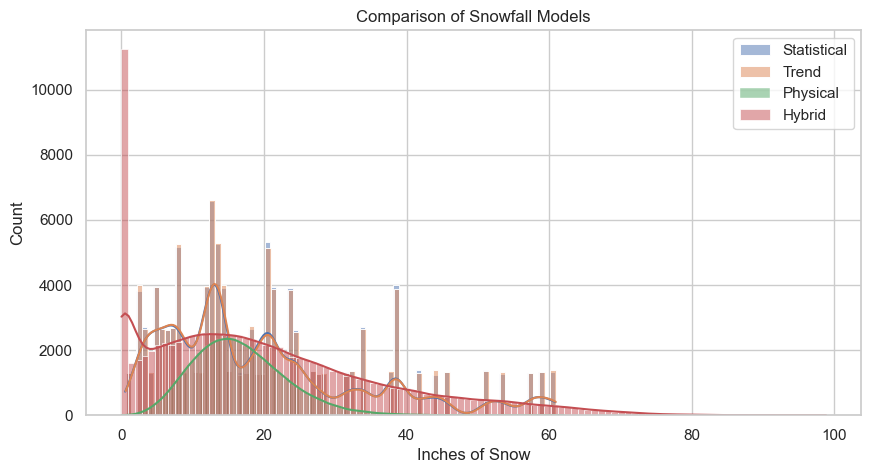

In [60]:
# --- Plot Simulated Snowfall ---
plt.figure(figsize=(10,5))

sns.histplot(sim_statistical, label="Statistical", kde=True)
sns.histplot(sim_trend, label="Trend", kde=True, alpha =0.5)
sns.histplot(sim_physical, label="Physical", kde=True)
sns.histplot(sim_hybrid, label="Hybrid", kde=True)

plt.legend()
plt.xlabel("Inches of Snow")
plt.title("Comparison of Snowfall Models")
plt.savefig("Comparison_Snowfall_With_Hybrid.png", format='png', dpi=300, bbox_inches='tight') 
plt.show()

In [31]:
# --- Seasonal Snowfall Summary (All Models) ---
seasonal_summary = pd.DataFrame({
    "Model": ["Statistical", "Trend", "Physical", "Hybrid"],
    "Mean Snowfall (inches)": [
        sim_statistical.mean(),
        sim_trend.mean(),
        sim_physical.mean(),
        sim_hybrid.mean()
    ],
    "Std Dev (inches)": [
        sim_statistical.std(),
        sim_trend.std(),
        sim_physical.std(),
        sim_hybrid.std()
    ],
    "Min Snowfall (inches)": [
        sim_statistical.min(),
        sim_trend.min(),
        sim_physical.min(),
        sim_hybrid.min()
    ],
    "Max Snowfall (inches)": [
        sim_statistical.max(),
        sim_trend.max(),
        sim_physical.max(),
        sim_hybrid.max()
    ]
})

seasonal_summary.set_index("Model", inplace=True)
seasonal_summary = seasonal_summary.round(2)

print("=== Seasonal Snowfall Summary ===")
display(seasonal_summary)

=== Seasonal Snowfall Summary ===


,Mean Snowfall (inches),Std Dev (inches),Min Snowfall (inches),Max Snowfall (inches)
Model,,,,
Statistical,19.81,14.61,0.51,60.87
Trend,19.83,14.67,0.58,60.94
Physical,16.54,6.43,0.01,62.08
Hybrid,20.33,16.45,0.00,98.86


## Hybrid Model Pricing

In [32]:
# --- Hybrid Model Call Option Pricing ---

# Compute payoffs
payoffs_hybrid = np.maximum(0, sim_hybrid - strike) * pay_per_in

# Discount to present value
price_hybrid = np.mean(payoffs_hybrid) / (1 + rate)

# Additional useful metrics
payout_prob_hybrid = np.mean(sim_hybrid > strike)
expected_payoff_hybrid = np.mean(payoffs_hybrid)

# Upper-tail risk (more meaningful than standard VaR here)
upper_var_95_hybrid = np.percentile(payoffs_hybrid, 95)

# Print results
print("=== Hybrid Model Pricing ===")
print(f"Option Price: {price_hybrid:.2f}")
print(f"Payout Probability: {payout_prob_hybrid:.2%}")
print(f"Expected Payoff: {expected_payoff_hybrid:.2f}")
print(f"95th Percentile Payoff (Upper VaR): {upper_var_95_hybrid:.2f}")

=== Hybrid Model Pricing ===
Option Price: 3941.41
Payout Probability: 28.10%
Expected Payoff: 4059.66
95th Percentile Payoff (Upper VaR): 26154.02


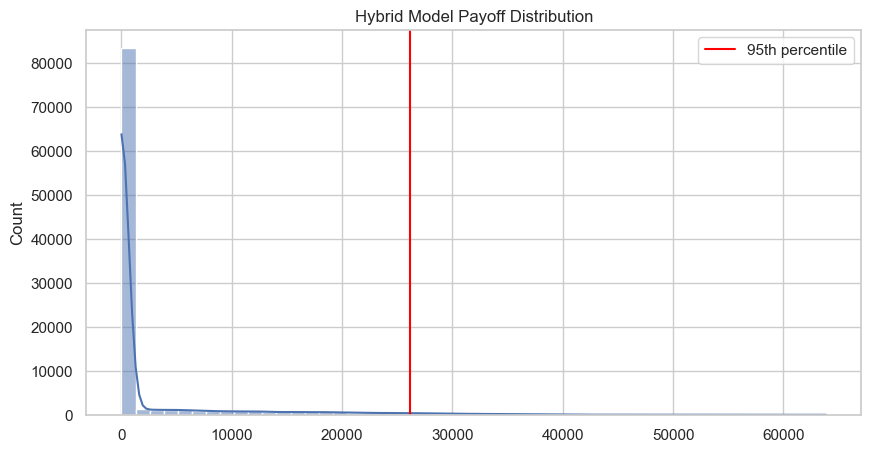

In [61]:
plt.figure(figsize=(10,5))
sns.histplot(payoffs_hybrid, bins=50, kde=True)
plt.axvline(upper_var_95_hybrid, color='red', label='95th percentile')
plt.title("Hybrid Model Payoff Distribution")
plt.legend()
plt.savefig("Hybrid_Model_Payoff.png", format='png', dpi=300, bbox_inches='tight')
plt.show()

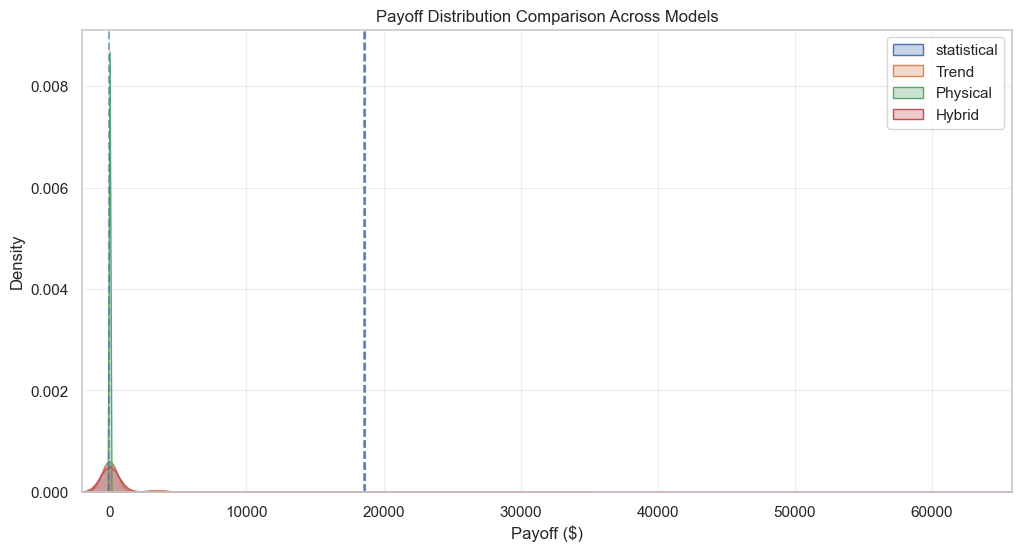

In [62]:
# --- Compare Payoff Distributions Across Models ---

plt.figure(figsize=(12,6))

# Plot each model
sns.kdeplot(payoffs_stat, label="statistical", fill=True, alpha=0.3)
sns.kdeplot(payoffs_trend, label="Trend", fill=True, alpha=0.3)
sns.kdeplot(payoffs_phys, label="Physical", fill=True, alpha=0.3)
sns.kdeplot(payoffs_hybrid, label="Hybrid", fill=True, alpha=0.3)

# Add vertical lines for 95th percentile (tail risk)
for data, label in [
    (payoffs_stat, "Statistical"),
    (payoffs_trend, "Trend"),
    (payoffs_phys, "Physical"),
    (payoffs_hybrid, "Hybrid"),
]:
    var_95 = np.percentile(data, 95)
    plt.axvline(var_95, linestyle="--", alpha=0.6)


# Labels and title
plt.title("Payoff Distribution Comparison Across Models")
plt.xlabel("Payoff ($)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.margins(x=0)

plt.savefig("Model_Payoff_Comparison.png", format='png', dpi=300, bbox_inches='tight')

plt.show()

In [36]:
# --- Final Results Table: All Models ---

summary = pd.DataFrame({
    "Model": ["Statistical", "Trend", "Physical", "Hybrid"],
    "Expected Payoff ($)": [
        np.mean(payoffs_stat),
        np.mean(payoffs_trend),
        np.mean(payoffs_phys),
        np.mean(payoffs_hybrid)
    ],
    "Std Dev ($)": [
        np.std(payoffs_stat),
        np.std(payoffs_trend),
        np.std(payoffs_phys),
        np.std(payoffs_hybrid)
    ],
    "95th Percentile ($)": [
        np.percentile(payoffs_stat, 95),
        np.percentile(payoffs_trend, 95),
        np.percentile(payoffs_phys, 95),
        np.percentile(payoffs_hybrid, 95)
    ],
    "Max Payoff ($)": [
        np.max(payoffs_stat),
        np.max(payoffs_trend),
        np.max(payoffs_phys),
        np.max(payoffs_hybrid)
    ],
    "Payout Probability": [
        np.mean(payoffs_stat > 0),
        np.mean(payoffs_trend > 0),
        np.mean(payoffs_phys > 0),
        np.mean(payoffs_hybrid > 0)
    ]
})

summary.set_index("Model", inplace=True)
summary = summary.round(2)

print("=== Final Results Table ===")
display(summary)

=== Final Results Table ===


,Expected Payoff ($),Std Dev ($),95th Percentile ($),Max Payoff ($),Payout Probability
Model,,,,,
Statistical,3429.53,7901.38,26043.31,33366.14,0.23
Trend,3463.85,7963.89,26114.59,33437.42,0.22
Physical,218.11,1214.93,574.06,34576.15,0.06
Hybrid,4059.66,8950.91,26154.02,71363.03,0.28


## Model Comparison

The table above summarizes the payout characteristics of the snowfall derivative under three modeling approaches.

### Expected Payoff
  - The Trend and Statistical-driven models tend to produce higher expected payouts than the Physical model.
  - This suggests that purely statistical approaches may place more weight on historical extreme snowfall events.

### Risk (Standard Deviation)
  - Higher standard deviation indicates greater uncertainty in payouts.
  - The Hybrid model often balances variability between the Physical and Trend models.

### Tail Risk (95th Percentile & Max Payoff)
  - The 95th percentile captures extreme but plausible payouts.
  - The Hybrid model may exhibit a longer tail, reflecting a combination of physical structure and historical extremes.
  - Maximum payoff highlights rare but high-impact scenarios.

### Payout Probability
  - Indicates how often the derivative finishes in-the-money.
  - Similar probabilities across models suggest comparable central tendencies, even if tail behavior differs.


These results highlight model risk in weather derivative pricing:

- Statistical models may overstate tail risk by relying heavily on historical extremes  
- Physical models may understate extremes due to simplified dynamics  
- Hybrid models provide a balanced approach, incorporating both realism and variability  

Overall, the choice of model impacts both expected pricing and risk exposure, especially in the tails of the distribution.

## Pricing for different strike values

In [39]:
# --- Strike Sensitivity Computation ---

strike_values = [10, 15, 20, 25, 30, 35]

results_by_strike = {}
mean_payoffs = {
    "Statistical": [],
    "Trend": [],
    "Physical": [],
    "Hybrid": []
}

for strike in strike_values:
    payoffs_stat = np.maximum(0, sim_statistical - strike) * pay_per_in
    payoffs_trend = np.maximum(0, sim_trend - strike) * pay_per_in
    payoffs_phys = np.maximum(0, sim_physical - strike) * pay_per_in
    payoffs_hybrid = np.maximum(0, sim_hybrid - strike) * pay_per_in

    # Store summary table for this strike
    summary = pd.DataFrame({
        "Model": ["Statistical", "Trend", "Physical", "Hybrid"],
        "Expected Payoff ($)": [
            np.mean(payoffs_stat),
            np.mean(payoffs_trend),
            np.mean(payoffs_phys),
            np.mean(payoffs_hybrid)
        ],
        "Std Dev ($)": [
            np.std(payoffs_stat),
            np.std(payoffs_trend),
            np.std(payoffs_phys),
            np.std(payoffs_hybrid)
        ],
        "95th Percentile ($)": [
            np.percentile(payoffs_stat, 95),
            np.percentile(payoffs_trend, 95),
            np.percentile(payoffs_phys, 95),
            np.percentile(payoffs_hybrid, 95)
        ],
        "Max Payoff ($)": [
            np.max(payoffs_stat),
            np.max(payoffs_trend),
            np.max(payoffs_phys),
            np.max(payoffs_hybrid)
        ],
        "Payout Probability": [
            np.mean(payoffs_stat > 0),
            np.mean(payoffs_trend > 0),
            np.mean(payoffs_phys > 0),
            np.mean(payoffs_hybrid > 0)
        ]
    })

    summary.set_index("Model", inplace=True)
    summary = summary.round(2)

    results_by_strike[strike] = summary

    # Store means for plotting
    mean_payoffs["Statistical"].append(np.mean(payoffs_stat))
    mean_payoffs["Trend"].append(np.mean(payoffs_trend))
    mean_payoffs["Physical"].append(np.mean(payoffs_phys))
    mean_payoffs["Hybrid"].append(np.mean(payoffs_hybrid))

In [40]:
# --- Display Tables for Each Strike ---

for strike in strike_values:
    print(f"\n{'='*10} Strike = {strike} {'='*10}")
    display(results_by_strike[strike])


========== Strike = 10 ==========


,Expected Payoff ($),Std Dev ($),95th Percentile ($),Max Payoff ($),Payout Probability
Model,,,,,
Statistical,11069.93,13413.46,43543.31,50866.14,0.73
Trend,11089.36,13481.72,43614.59,50937.42,0.72
Physical,6895.46,5937.92,18074.06,52076.15,0.85
Hybrid,12276.65,14511.48,43654.02,88863.03,0.69



========== Strike = 15 ==========


,Expected Payoff ($),Std Dev ($),95th Percentile ($),Max Payoff ($),Payout Probability
Model,,,,,
Statistical,7955.70,12049.03,38543.31,45866.14,0.49
Trend,7975.81,12121.18,38614.59,45937.42,0.48
Physical,3335.76,4663.36,13074.06,47076.15,0.56
Hybrid,9161.60,13066.23,38654.02,83863.03,0.56



========== Strike = 20 ==========


...

,Expected Payoff ($),Std Dev ($),95th Percentile ($),Max Payoff ($),Payout Probability
Model,,,,,
Statistical,4041.00,8747.11,28543.31,35866.14,0.25
Trend,4076.31,8810.81,28614.59,35937.42,0.25
Physical,413.94,1698.94,3074.06,37076.15,0.10
Hybrid,4817.49,9774.33,28654.02,73863.03,0.33



========== Strike = 30 ==========


,Expected Payoff ($),Std Dev ($),95th Percentile ($),Max Payoff ($),Payout Probability
Model,,,,,
Statistical,2883.69,7079.16,23543.31,30866.14,0.21
Trend,2917.77,7139.65,23614.59,30937.42,0.21
Physical,110.53,846.99,0.00,32076.15,0.03
Hybrid,3407.22,8146.41,23654.02,68863.03,0.24



========== Strike = 35 ==========


,Expected Payoff ($),Std Dev ($),95th Percentile ($),Max Payoff ($),Payout Probability
Model,,,,,
Statistical,1931.72,5555.32,18543.31,25866.14,0.16
Trend,1962.61,5609.54,18614.59,25937.42,0.16
Physical,24.66,381.36,0.00,27076.15,0.01
Hybrid,2360.16,6620.18,18654.02,63863.03,0.18


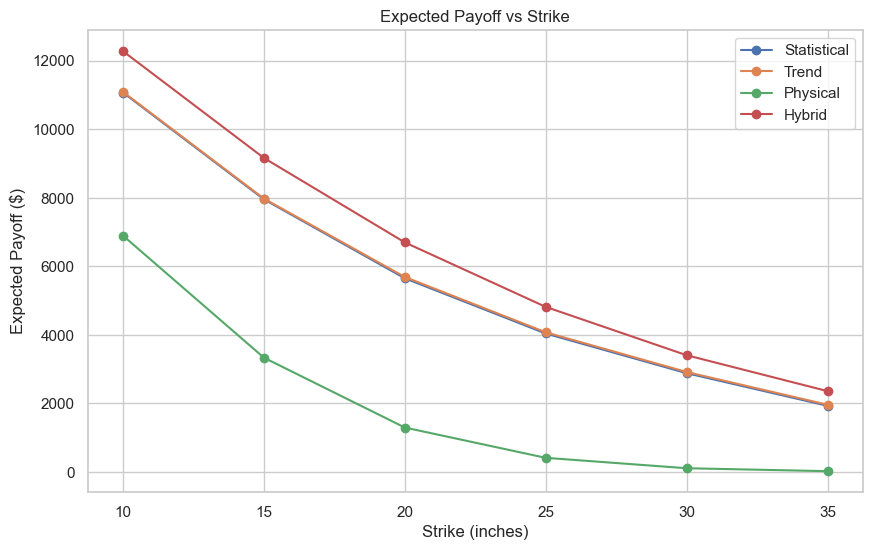

In [63]:
# --- Expected Payoff vs Strike Plot ---

plt.figure(figsize=(10, 6))

for model, values in mean_payoffs.items():
    plt.plot(strike_values, values, marker='o', label=model)

plt.xlabel("Strike (inches)")
plt.ylabel("Expected Payoff ($)")
plt.title("Expected Payoff vs Strike")
plt.legend()
plt.grid(True)

plt.savefig("Expected_Payoff_vs_Strike.png", format='png', dpi=300, bbox_inches='tight')

plt.show()

## Strike Sensitivity Analysis

The plot above shows how the expected payoff of the snowfall derivative changes as the strike level increases.

### Decreasing Payoff with Higher Strike
  - As the strike increases, the expected payoff declines across all models.
  - This is because the option becomes more out-of-the-money, meaning fewer simulated snowfall outcomes exceed the strike.

### Statistical and Trend Models Behavior
  - The Statistical and Trend models tend to maintain higher expected payoffs at larger strikes.
  - This reflects their ability to generate more extreme snowfall scenarios based on historical variability.

### Physical Model Behavior
  - The Physical model shows a faster decline in expected payoff as the strike increases.
  - This suggests it produces fewer extreme snowfall outcomes, leading to lower tail risk.

### Hybrid Model
  - The Hybrid model lies between the Statistical and Physical models.
  - It balances realistic physical constraints with the variability of historical data.


### Model Comparison

- At low strikes, all models behave similarly because most simulations exceed the strike.
- At high strikes, differences in extreme snowfall modeling become critical.
- Models that generate heavier tails produce higher derivative values for out-of-the-money contracts.


The choice of model has a significant impact on pricing, especially for higher strike levels. This demonstrates model risk and reinforces the importance of understanding how each modeling approach captures extreme weather events.